# Sistem Pendukung Keputusan Rekomendasi Game Steam Menggunakan Metode SAW

## Pendahuluan

Dalam banyaknya game yang tersedia di platform Steam, pengguna sering mengalami kesulitan dalam menentukan game yang sesuai dengan preferensi mereka. Faktor seperti harga, jumlah review, diskon, dan dukungan bahasa menjadi pertimbangan penting sebelum membeli game.

Oleh karena itu, pada proyek ini dibuat sebuah Sistem Pendukung Keputusan (SPK) menggunakan metode Simple Additive Weighting (SAW) untuk membantu memberikan rekomendasi game terbaik berdasarkan beberapa kriteria.

Metode SAW dipilih karena:
- sederhana,
- mudah diimplementasikan,
- mampu memberikan hasil perangkingan berdasarkan bobot tiap kriteria.

## Import Library

Library yang digunakan pada proyek ini meliputi:
- pandas → manipulasi data
- numpy → operasi numerik
- matplotlib → visualisasi data

In [533]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [534]:
df = pd.read_csv('merged_data.csv')

df.head()

,Title,Original Price,Discounted Price,Release Date,Link,Game Description,Recent Reviews Summary,All Reviews Summary,Recent Reviews Number,All Reviews Number,Developer,Publisher,Supported Languages,Popular Tags,Game Features,Minimum Requirements
0,Baldur's Gate 3,$29.99,$29.99,"3 Aug, 2023",https://store.steampowered.com/app/1086940/Bal...,"Baldur’s Gate 3 is a story-rich, party-based R...",Overwhelmingly Positive,Very Positive,"- 96% of the 128,900 user reviews in the last ...","- 94% of the 188,617 user reviews for this gam...",Larian Studios,Larian Studios,"['English', 'French', 'German', 'Spanish - Spa...","['RPG', 'Choices Matter', 'Character Customiza...","['Single-player', 'Online Co-op', 'LAN Co-op',...",Requires a 64-bit processor and operating syst...
1,Counter-Strike: Global Offensive,$14.99,$14.99,"21 Aug, 2012",https://store.steampowered.com/app/730/Counter...,Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,Very Positive,"- 89% of the 75,284 user reviews in the last 3...","- 88% of the 7,428,921 user reviews for this g...","Valve, Hidden Path Entertainment",Valve,"['English', 'Czech', 'Danish', 'Dutch', 'Finni...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","['Steam Achievements', 'Full controller suppor...",OS: | Windows® 7/Vista/XP | Processor: | Int...
2,Apex Legends™,Free,Free,"4 Nov, 2020",https://store.steampowered.com/app/1172470/Ape...,"Apex Legends is the award-winning, free-to-pla...",Mixed,Very Positive,"- 65% of the 18,581 user reviews in the last 3...","- 80% of the 701,597 user reviews for this gam...",Respawn Entertainment,Electronic Arts,"['English', 'French', 'Italian', 'German', 'Sp...","['Free to Play', 'Multiplayer', 'Battle Royale...","['Online PvP', 'Online Co-op', 'Steam Achievem...",Requires a 64-bit processor and operating syst...
3,Forza Horizon 5,$34.78,$17.39,"8 Nov, 2021",https://store.steampowered.com/app/1551360/For...,Your Ultimate Horizon Adventure awaits! Explor...,Very Positive,Very Positive,"- 87% of the 4,120 user reviews in the last 30...","- 88% of the 123,162 user reviews for this gam...",Playground Games,Xbox Game Studios,"['English', 'French', 'Italian', 'German', 'Sp...","['Racing', 'Open World', 'Driving', 'Multiplay...","['Single-player', 'Online PvP', 'Online Co-op'...",Requires a 64-bit processor and operating syst...
4,Call of Duty®,Free,Free,"27 Oct, 2022",https://store.steampowered.com/app/1938090/Cal...,"Welcome to Call of Duty® HQ, the home of Call ...",Mixed,Mixed,"- 49% of the 8,257 user reviews in the last 30...","- 57% of the 236,876 user reviews for this gam...","Infinity Ward, Raven Software, Beenox, Treyarc...",Activision,"['English', 'French', 'Italian', 'German', 'Sp...","['FPS', 'Multiplayer', 'Shooter', 'Action', 'S...","['Single-player', 'Online PvP', 'Online Co-op'...",Requires a 64-bit processor and operating syst...


## Data Understanding

Tahap ini dilakukan untuk memahami struktur dataset, tipe data, serta mengecek apakah terdapat data kosong atau tidak valid.

In [535]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71700 entries, 0 to 71699
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Title                   71699 non-null  str  
 1   Original Price          71700 non-null  str  
 2   Discounted Price        71700 non-null  str  
 3   Release Date            71569 non-null  str  
 4   Link                    71700 non-null  str  
 5   Game Description        71489 non-null  str  
 6   Recent Reviews Summary  56480 non-null  str  
 7   All Reviews Summary     5371 non-null   str  
 8   Recent Reviews Number   56480 non-null  str  
 9   All Reviews Number      5371 non-null   str  
 10  Developer               71479 non-null  str  
 11  Publisher               71183 non-null  str  
 12  Supported Languages     71700 non-null  str  
 13  Popular Tags            71700 non-null  str  
 14  Game Features           71700 non-null  str  
 15  Minimum Requirements    70576 

In [536]:
df.describe()

,Title,Original Price,Discounted Price,Release Date,Link,Game Description,Recent Reviews Summary,All Reviews Summary,Recent Reviews Number,All Reviews Number,Developer,Publisher,Supported Languages,Popular Tags,Game Features,Minimum Requirements
count,71699,71700,71700,71569,71700,71489,56480,5371,56480,5371,71479,71183,71700,71700,71700,70576
unique,71699,654,827,4441,71700,71090,18,7,13391,5296,45353,38543,11058,65817,5418,63201
top,Baldur's Gate 3,Free,Free,Coming soon,https://store.steampowered.com/app/1086940/Bal...,Find the objects that are hidden on the map.,Very Positive,Very Positive,- Need more user reviews to generate a score,- 90% of the 624 user reviews for this game ar...,Choice of Games,Big Fish Games,['English'],"['Indie', 'Casual']",['Single-player'],Requires a 64-bit processor and operating syst...
freq,1,17585,17585,5887,1,34,11039,3151,18999,3,162,459,38083,284,17262,274


In [537]:
df.isnull().sum()

Title                         1
Original Price                0
Discounted Price              0
Release Date                131
Link                          0
Game Description            211
Recent Reviews Summary    15220
All Reviews Summary       66329
Recent Reviews Number     15220
All Reviews Number        66329
Developer                   221
Publisher                   517
Supported Languages           0
Popular Tags                  0
Game Features                 0
Minimum Requirements       1124
dtype: int64

## Data Cleaning & Preprocessing

### Data Awal

In [538]:
print("Jumlah data awal:")
print(df.shape)

Jumlah data awal:
(71700, 16)


### Hapus Data Bernilai Null

In [539]:
important_cols = [
    'Original Price',
    'Recent Reviews Number',
    'All Reviews Number',
    'Supported Languages',
    'Game Features'
]

df = df.dropna(subset=important_cols)

print("\nJumlah data setelah hapus null:")
print(df.shape)


Jumlah data setelah hapus null:
(5371, 16)


### Membersihkan Harga

In [540]:
df['Original Price'] = (
    df['Original Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

### Extract Angka Review

In [541]:
df['Recent Reviews Number'] = (
    df['Recent Reviews Number']
    .astype(str)
    .str.extract(r'of the ([\d,]+)')[0]
    .str.replace(',', '', regex=False)
    .astype(int)
)

df['All Reviews Number'] = (
    df['All Reviews Number']
    .astype(str)
    .str.extract(r'of the ([\d,]+)')[0]
    .str.replace(',', '', regex=False)
    .astype(int)
)

### Konversi Ke Numerik

In [542]:
numeric_cols = [
    'Original Price',
    'Recent Reviews Number',
    'All Reviews Number'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

### Hapus Data Invalid

In [543]:
df = df.dropna(subset=numeric_cols)

df = df[df['Original Price'] >= 0]

print("\nJumlah data setelah cleaning:")
print(df.shape)


Jumlah data setelah cleaning:
(4438, 16)


## Feature Engineering

Tahap ini digunakan untuk membuat fitur tambahan yang dapat digunakan sebagai kriteria dalam metode SAW.

### Menghitung Jumlah Bahasa

Jumlah bahasa dihitung berdasarkan banyaknya bahasa yang didukung oleh game.

In [544]:
df['Language Count'] = df['Supported Languages'].apply(
    lambda x: len(str(x).split(','))
)

### Jumlah Fitur

Jumlah fitur dihitung dari banyaknya fitur yang ada di dalam suatu game.

In [545]:
df['Feature Count'] = df['Game Features'].apply(
    lambda x: len(str(x).split(','))
)
print(df.shape)

(4438, 18)


### Filter Game Populer

Hanya game dengan jumlah review di atas 100000 yang digunakan dalam proses SAW.

In [546]:
df = df[df['All Reviews Number'] >= 100000]

print("\nJumlah data setelah filter review:")
print(df.shape)


Jumlah data setelah filter review:
(104, 18)


### Log Transformation

Transformasi log digunakan untuk mengurangi ketimpangan data review yang terlalu besar.

In [547]:
df['Recent Reviews Number'] = np.log1p(
    df['Recent Reviews Number']
)

df['All Reviews Number'] = np.log1p(
    df['All Reviews Number']
)

### Cek Hasil

In [548]:

print("\nInformasi Dataset:")
print(df.info())

print("\n5 Data Teratas:")
print(df.head())


Informasi Dataset:
<class 'pandas.DataFrame'>
Index: 104 entries, 0 to 36140
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Title                   104 non-null    str    
 1   Original Price          104 non-null    float64
 2   Discounted Price        104 non-null    str    
 3   Release Date            104 non-null    str    
 4   Link                    104 non-null    str    
 5   Game Description        104 non-null    str    
 6   Recent Reviews Summary  104 non-null    str    
 7   All Reviews Summary     104 non-null    str    
 8   Recent Reviews Number   104 non-null    float64
 9   All Reviews Number      104 non-null    float64
 10  Developer               104 non-null    str    
 11  Publisher               104 non-null    str    
 12  Supported Languages     104 non-null    str    
 13  Popular Tags            104 non-null    str    
 14  Game Features           104 non-null

## Kriteria yang digunakan dalam metode SAW terdiri dari:

| Kriteria | Jenis |
|---|---|
| Original Price | Cost |
| Recent Reviews Number | Benefit |
| All Reviews Number | Benefit |
| Language Count | Benefit |
| Feature Count | Benefit |

Keterangan:
- Harga semakin murah semakin baik
- Review semakin tinggi semakin baik
- Jumlah bahasa semakin banyak semakin baik
- Jumlah fitur semakin banyak semakin baik


In [549]:
weights = {
    'Original Price': 0.20,
    'Recent Reviews Number': 0.25,
    'All Reviews Number': 0.30,
    'Language Count': 0.10,
    'Feature Count': 0.15
}

## Pemilihan Alternatif

Alternatif game dipilih dari dataset yang telah dibersihkan.

In [550]:
df_saw = df.copy()

## Membuat Matriks Keputusan

Matriks keputusan digunakan sebagai dasar perhitungan metode SAW.

In [551]:
criteria = [
    'Original Price',
    'Recent Reviews Number',
    'All Reviews Number',
    'Language Count',
    'Feature Count'
]

X = df_saw[criteria].copy()

X.head()

,Original Price,Recent Reviews Number,All Reviews Number,Language Count,Feature Count
0,29.99,11.766800,12.147479,13,6
1,14.99,11.229036,15.820891,28,10
3,34.78,8.323851,11.721264,16,8
7,29.99,8.577912,13.221711,18,5
8,19.99,9.248984,13.569281,25,11


## Normalisasi Matriks

Normalisasi dilakukan agar seluruh nilai kriteria berada pada skala yang sama.

In [552]:
normalized = pd.DataFrame()

### Kriteria Cost

Untuk kriteria cost digunakan rumus:

Rij = Min(Xij) / Xij

In [553]:
normalized['C1'] = (
    X['Original Price'].min()
    / X['Original Price']
)

### Kriteria Benefit

Untuk kriteria benefit digunakan rumus:
Rij = Xij / Max(Xij)

In [554]:
normalized['C2'] = (
    X['Recent Reviews Number']
    / X['Recent Reviews Number'].max()
)

normalized['C3'] = (
    X['All Reviews Number']
    / X['All Reviews Number'].max()
)

normalized['C4'] = (
    X['Language Count']
    / X['Language Count'].max()
)

normalized['C5'] = (
    X['Feature Count']
    / X['Feature Count'].max()
)

## Matriks Normalisasi

In [555]:
normalized.head()

,C1,C2,C3,C4,C5
0,0.046349,1.000000,0.767813,0.433333,0.352941
1,0.092728,0.954298,1.000000,0.933333,0.588235
3,0.039965,0.707401,0.740873,0.533333,0.470588
7,0.046349,0.728993,0.835712,0.600000,0.294118
8,0.069535,0.786024,0.857681,0.833333,0.647059


## Perhitungan Nilai Preferensi

Nilai preferensi dihitung menggunakan penjumlahan terbobot dari seluruh kriteria.

In [556]:
weights_array = np.array([
    0.20,
    0.25,
    0.30,
    0.10,
    0.15
])

scores = normalized.dot(weights_array)

## Menambahkan Skor SAW ke Dataset

In [557]:
df_saw['SAW Score'] = scores

## Perangkingan Game

Game diurutkan berdasarkan nilai SAW tertinggi.

In [558]:
ranking = df_saw.sort_values(
    by='SAW Score',
    ascending=False
)

ranking.head(10)

,Title,Original Price,Discounted Price,Release Date,Link,Game Description,Recent Reviews Summary,All Reviews Summary,Recent Reviews Number,All Reviews Number,Developer,Publisher,Supported Languages,Popular Tags,Game Features,Minimum Requirements,Language Count,Feature Count,SAW Score
1,Counter-Strike: Global Offensive,14.99,$14.99,"21 Aug, 2012",https://store.steampowered.com/app/730/Counter...,Counter-Strike: Global Offensive (CS: GO) expa...,Very Positive,Very Positive,11.229036,15.820891,"Valve, Hidden Path Entertainment",Valve,"['English', 'Czech', 'Danish', 'Dutch', 'Finni...","['FPS', 'Shooter', 'Multiplayer', 'Competitive...","['Steam Achievements', 'Full controller suppor...",OS: | Windows® 7/Vista/XP | Processor: | Int...,28,10,0.738689
102,Left 4 Dead 2,6.29,$6.29,"16 Nov, 2009",https://store.steampowered.com/app/550/Left_4_...,"Set in the zombie apocalypse, Left 4 Dead 2 (L...",Overwhelmingly Positive,Overwhelmingly Positive,9.168372,13.253728,Valve,Valve,"['English', 'Danish', 'Dutch', 'Finnish', 'Fre...","['Zombies', 'Co-op', 'FPS', 'Multiplayer', 'Sh...","['Single-player', 'Online PvP', 'Online Co-op'...",OS: | Windows® 7 32/64-bit / Vista 32/64 / XP...,28,17,0.733644
92,Garry's Mod,6.99,$6.99,"29 Nov, 2006",https://store.steampowered.com/app/4000/Garrys...,Garry's Mod is a physics sandbox. There aren't...,Overwhelmingly Positive,Overwhelmingly Positive,9.324918,13.651232,Facepunch Studios,Valve,"['English', 'French', 'Italian', 'German', 'Sp...","['Sandbox', 'Multiplayer', 'Funny', 'Moddable'...","['Single-player', 'Online PvP', 'LAN PvP', 'On...",OS: | Windows® XP/Vista | Processor: | 2 GHz...,25,14,0.703611
335,Portal 2,6.29,$6.29,"18 Apr, 2011",https://store.steampowered.com/app/620/Portal_...,"The ""Perpetual Testing Initiative"" has been ex...",Overwhelmingly Positive,Overwhelmingly Positive,8.438583,12.582167,Valve,Valve,"['English', 'French', 'German', 'Spanish - Spa...","['Platformer', 'Puzzle', 'Dark Humor', 'First-...","['Single-player', 'Online Co-op', 'Shared/Spli...",OS: | Windows 7 / Vista / XP | Processor: | ...,27,16,0.693248
13,Team Fortress 2,10.49,$10.49,"10 Oct, 2007",https://store.steampowered.com/app/440/Team_Fo...,Nine distinct classes provide a broad range of...,Very Positive,Very Positive,9.474088,13.794352,Valve,Valve,"['English', 'Danish', 'Dutch', 'Finnish', 'Fre...","['Free to Play', 'Hero Shooter', 'Multiplayer'...","['Cross-Platform Multiplayer', 'Steam Achievem...",OS: | Windows® 7 (32/64-bit)/Vista/XP | Proce...,26,13,0.690735
41,Euro Truck Simulator 2,10.99,$10.99,"12 Oct, 2012",https://store.steampowered.com/app/227300/Euro...,"Travel across Europe as king of the road, a tr...",Overwhelmingly Positive,Overwhelmingly Positive,9.149847,13.103240,SCS Software,SCS Software,"['English', 'German', 'French', 'Italian', 'Ko...","['Driving', 'Transportation', 'Simulation', 'O...","['Single-player', 'Online Co-op', 'Steam Achie...",OS: | Windows 7 | Processor: | Dual core CPU...,25,11,0.648555
8,Rust,19.99,$19.99,"8 Feb, 2018",https://store.steampowered.com/app/252490/Rust...,The only aim in Rust is to survive. Everything...,Very Positive,Very Positive,9.248984,13.569281,Facepunch Studios,Facepunch Studios,"['English', 'French', 'Italian', 'German', 'Sp...","['Survival', 'Crafting', 'Multiplayer', 'Open ...","['MMO', 'Online PvP', 'Online Co-op', 'Cross-P...",Requires a 64-bit processor and operating syst...,25,11,0.648109
216,Among Us,2.99,$2.99,"16 Nov, 2018",https://store.steampowered.com/app/945360/Amon...,An online and local party game of teamwork and...,Very Positive,Very Positive,8.052933,13.282634,Innersloth,Innersloth,"['English', 'Portuguese - Brazil', 'Spanish - ...","['Multiplayer', 'Online Co-Op', 'Social Deduct...","['Online PvP', 'LAN PvP', 'Online Co-op', 'LAN...",OS: | Windows 10 x32bit | Processor: | INTEL...,14,8,0.633195
21,Phasmophobia,7.99,$7.99,"18 Sep, 2020",https://store.steampowered.com/app/739630/Phas...,Phasmophobia is a 4 player online co-op psycho...,Very Po

## Top 10 Rekomendasi Game

In [559]:
top10 = ranking[[
    'Title',
    'Original Price',
    'Recent Reviews Number',
    'All Reviews Number',
    'Language Count',
    'Feature Count',
    'SAW Score'
]].head(10)

top10

,Title,Original Price,Recent Reviews Number,All Reviews Number,Language Count,Feature Count,SAW Score
1,Counter-Strike: Global Offensive,14.99,11.229036,15.820891,28,10,0.738689
102,Left 4 Dead 2,6.29,9.168372,13.253728,28,17,0.733644
92,Garry's Mod,6.99,9.324918,13.651232,25,14,0.703611
335,Portal 2,6.29,8.438583,12.582167,27,16,0.693248
13,Team Fortress 2,10.49,9.474088,13.794352,26,13,0.690735
41,Euro Truck Simulator 2,10.99,9.149847,13.103240,25,11,0.648555
8,Rust,19.99,9.248984,13.569281,25,11,0.648109
216,Among Us,2.99,8.052933,13.282634,14,8,0.633195
21,Phasmophobia,7.99,9.328301,13.071491,26,7,0.629281
14,Dota 2,92.62,9.907131,14.523701,28,5,0.626344


## Visualisasi Hasil Ranking

Visualisasi dilakukan untuk mempermudah pengguna melihat hasil rekomendasi game terbaik.

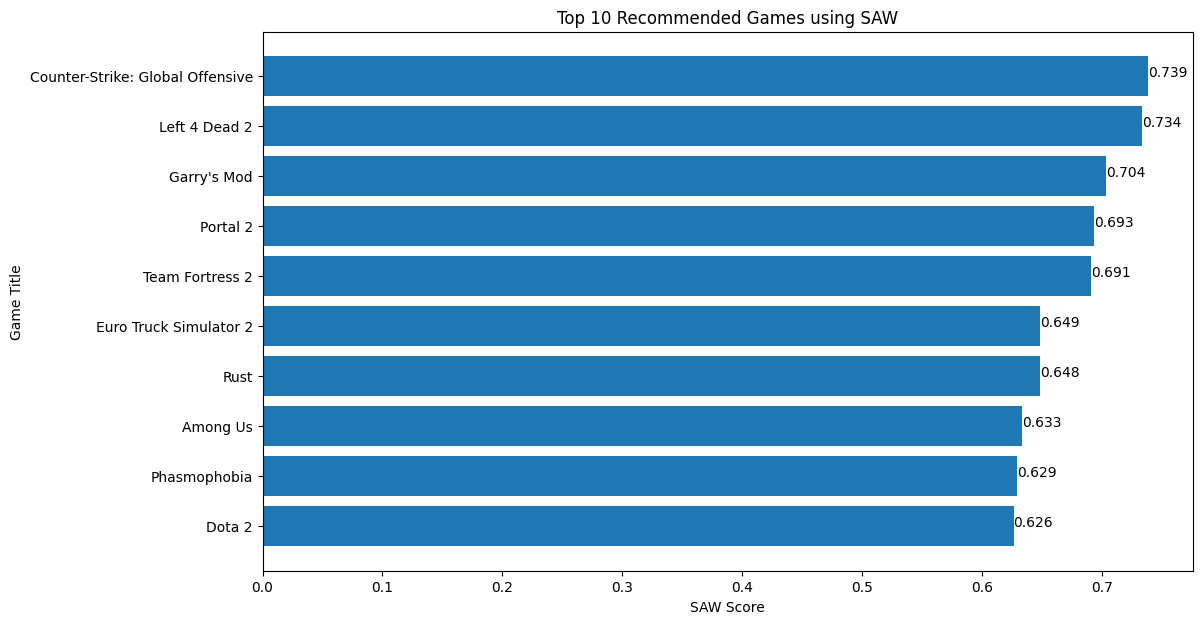

In [560]:
plt.figure(figsize=(12,7))

plt.barh(
    top10['Title'],
    top10['SAW Score']
)

plt.xlabel('SAW Score')
plt.ylabel('Game Title')
plt.title('Top 10 Recommended Games using SAW')

plt.gca().invert_yaxis()

for index, value in enumerate(top10['SAW Score']):
    plt.text(value, index, f'{value:.3f}')

plt.show()

## Kesimpulan

Berdasarkan hasil perhitungan menggunakan metode Simple Additive Weighting (SAW), sistem berhasil memberikan rekomendasi game terbaik berdasarkan beberapa kriteria seperti harga, jumlah review, dukungan bahasa, dan persentase diskon.

Metode SAW mampu membantu proses pengambilan keputusan dengan menghasilkan perangkingan game berdasarkan bobot setiap kriteria yang telah ditentukan.